In [17]:
# Best model for Potato
import tensorflow as tf 
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

EPOCHS = 30
BATCH_SIZE = 32
INPUT_SHAPE = (256, 256, 3)


# Load datasets
def load_dataset(directory):
    return tf.keras.preprocessing.image_dataset_from_directory(
        directory,
        batch_size=BATCH_SIZE,
        image_size=(256, 256),
        shuffle=True
    )

train_ds = load_dataset("/mnt/home/alwanai/virtualenv/potatoes/train")
test_ds = load_dataset("/mnt/home/alwanai/virtualenv/potatoes/test")
val_ds = load_dataset("/mnt/home/alwanai/virtualenv/potatoes/val")

input_shape = (256, 256, 3)  
n_classes = 3  

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)


resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(256, 256),
    tf.keras.layers.Rescaling(1.0 / 255)
])

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

model = models.Sequential([
    tf.keras.layers.InputLayer(shape=input_shape),
    resize_and_rescale,
    data_augmentation,
    tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(n_classes, activation='softmax')  
])

model.build(input_shape=(None, 256, 256, 3))
model.summary()

model.compile(
    optimizer = 'adam',
    loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    epochs = 50,
    batch_size=32,
    verbose= 1,
    validation_data = val_ds
)

Found 1506 files belonging to 3 classes.
Found 324 files belonging to 3 classes.
Found 322 files belonging to 3 classes.


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_14 (Sequential)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_15 (Sequential)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,587 (2.61 MB)

 Trainable params: 683,587 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 15s 270ms/step - accuracy: 0.4740 - loss: 0.9887 - val_accuracy: 0.5155 - val_loss: 0.8617
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 259ms/step - accuracy: 0.5769 - loss: 0.7845 - val_accuracy: 0.7764 - val_loss: 0.5376
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 226ms/step - accuracy: 0.7979 - loss: 0.5294 - val_accuracy: 0.8571 - val_loss: 0.3421
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 245ms/step - accuracy: 0.8295 - loss: 0.3802 - val_accuracy: 0.9410 - val_loss: 0.1943
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 259ms/step - accuracy: 0.8926 - loss: 0.3053 - val_accuracy: 0.9317 - val_loss: 0.1977
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 247ms/step - accuracy: 0.9178 - loss: 0.2202 - val_accuracy: 0.8540 - val_loss: 0.3447
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 253ms/step - accuracy: 0.9221 - loss: 0.2065 - val_accuracy: 0.9317 - val_loss: 0.2053
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 246ms/step - accuracy: 0.9471 - loss: 0.1665 - val_accu

In [18]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9725 - loss: 0.0858 
Test Loss: 0.09602644294500351, Test Accuracy: 0.9660493731498718


In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

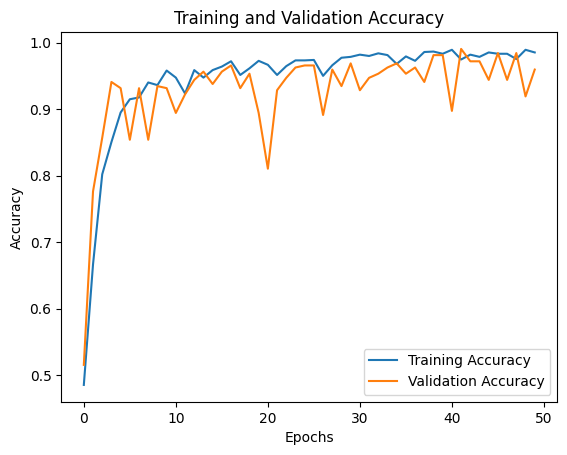

In [20]:
plt.plot(range(len(acc)), acc, label='Training Accuracy')
plt.plot(range(len(val_acc)), val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [21]:
# Best model for Potato
import tensorflow as tf 
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

EPOCHS = 30
BATCH_SIZE = 32
INPUT_SHAPE = (256, 256, 3)


# Load datasets
def load_dataset(directory):
    return tf.keras.preprocessing.image_dataset_from_directory(
        directory,
        batch_size=BATCH_SIZE,
        image_size=(256, 256),
        shuffle=True
    )

train_ds = load_dataset("/mnt/home/alwanai/virtualenv/potatoes/train")
test_ds = load_dataset("/mnt/home/alwanai/virtualenv/potatoes/test")
val_ds = load_dataset("/mnt/home/alwanai/virtualenv/potatoes/val")

input_shape = (256, 256, 3)  
n_classes = 3  

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)


resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(256, 256),
    tf.keras.layers.Rescaling(1.0 / 255)
])

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

model = models.Sequential([
    tf.keras.layers.InputLayer(shape=input_shape),
    resize_and_rescale,
    data_augmentation,
    tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(256, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(n_classes, activation='softmax')  
])

model.build(input_shape=(None, 256, 256, 3))
model.summary()

model.compile(
    optimizer = 'adam',
    loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    epochs = 50,
    batch_size=32,
    verbose= 1,
    validation_data = val_ds
)

Found 1506 files belonging to 3 classes.
Found 324 files belonging to 3 classes.
Found 322 files belonging to 3 classes.


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_17 (Sequential)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_18 (Sequential)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,126,083 (4.30 MB)

 Trainable params: 1,126,083 (4.30 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 249ms/step - accuracy: 0.4846 - loss: 0.9438 - val_accuracy: 0.6615 - val_loss: 0.7031
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - accuracy: 0.7423 - loss: 0.6216 - val_accuracy: 0.8882 - val_loss: 0.3564
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 239ms/step - accuracy: 0.8351 - loss: 0.4490 - val_accuracy: 0.8261 - val_loss: 0.4558
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 237ms/step - accuracy: 0.8230 - loss: 0.4444 - val_accuracy: 0.8758 - val_loss: 0.3299
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 236ms/step - accuracy: 0.8575 - loss: 0.3705 - val_accuracy: 0.8665 - val_loss: 0.3830
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 220ms/step - accuracy: 0.8388 - loss: 0.3870 - val_accuracy: 0.8540 - val_loss: 0.3566
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 238ms/step - accuracy: 0.9094 - loss: 0.2363 - val_accuracy: 0.8696 - val_loss: 0.3272
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 239ms/step - accuracy: 0.9243 - loss: 0.2213 - val_accu

In [22]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9841 - loss: 0.0558 
Test Loss: 0.12076990306377411, Test Accuracy: 0.9814814925193787


In [23]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

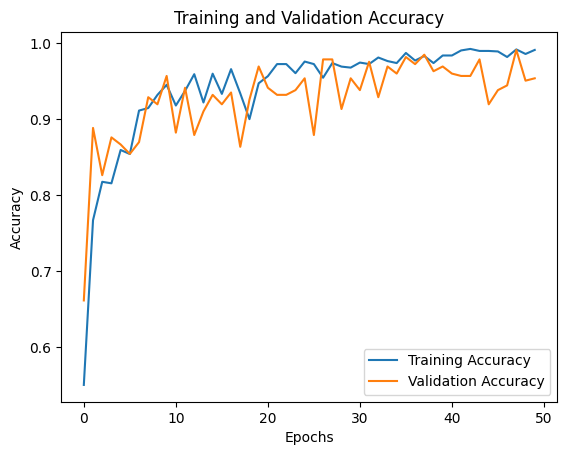

In [24]:
plt.plot(range(len(acc)), acc, label='Training Accuracy')
plt.plot(range(len(val_acc)), val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()